In [1]:
# ── Imports ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, ttest_ind
import warnings
warnings.filterwarnings("ignore")

# ── Plot style ─────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlepad"] = 12

# ── Load cleaned dataset ───────────────────────────────────────────────────
df = pd.read_csv("C:/Users/savin/Downloads/bank-marketing-analysis/data/bank_marketing_cleaned.csv")

print(f"✓ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nA/B Groups:")
print(df["prev_contacted"].value_counts())

✓ Dataset loaded: 41,176 rows × 25 columns

A/B Groups:
prev_contacted
No     39661
Yes     1515
Name: count, dtype: int64


In [2]:
# ── Group A: customers never previously contacted (control) ────────────────
group_a = df[df["prev_contacted"] == "No"]

# ── Group B: customers previously contacted (test) ────────────────────────
group_b = df[df["prev_contacted"] == "Yes"]

# ── Group summary ──────────────────────────────────────────────────────────
summary = pd.DataFrame({
    "Group"           : ["A — New Customers (Control)",
                         "B — Previously Contacted (Test)"],
    "Total Customers" : [len(group_a), len(group_b)],
    "Subscribed"      : [group_a["subscribed_num"].sum(),
                         group_b["subscribed_num"].sum()],
    "Did Not Subscribe": [len(group_a) - group_a["subscribed_num"].sum(),
                          len(group_b) - group_b["subscribed_num"].sum()],
    "Conversion Rate" : [f"{group_a['subscribed_num'].mean()*100:.2f}%",
                         f"{group_b['subscribed_num'].mean()*100:.2f}%"]
})

print("=" * 60)
print("A/B TEST GROUP SUMMARY")
print("=" * 60)
print(summary.to_string(index=False))

A/B TEST GROUP SUMMARY
                          Group  Total Customers  Subscribed  Did Not Subscribe Conversion Rate
    A — New Customers (Control)            39661        3672              35989           9.26%
B — Previously Contacted (Test)             1515         967                548          63.83%


In [3]:
# ── Build contingency table ────────────────────────────────────────────────
# A contingency table counts how many people fall into each combination
# of two categories: group (A/B) × outcome (subscribed/not subscribed)

contingency_table = pd.crosstab(
    df["prev_contacted"],
    df["subscribed"]
)

print("Contingency Table:")
print(contingency_table)

# ── Run chi-square test ────────────────────────────────────────────────────
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("\n" + "=" * 60)
print("CHI-SQUARE TEST — CONVERSION RATE DIFFERENCE")
print("=" * 60)
print(f"Chi-square statistic : {chi2:.4f}")
print(f"Degrees of freedom   : {dof}")
print(f"P-value              : {p_value:.10f}")
print("\n" + "=" * 60)

# ── Interpret the result ───────────────────────────────────────────────────
alpha = 0.05
print(f"Significance level   : {alpha}")
if p_value < alpha:
    print(f"Result               : SIGNIFICANT ✓")
    print(f"\nConclusion: The difference in conversion rates between")
    print(f"previously contacted (63.83%) and new customers (9.26%)")
    print(f"is statistically significant at the 95% confidence level.")
    print(f"This result is NOT due to random chance.")
else:
    print(f"Result               : NOT SIGNIFICANT ✗")
    print(f"Conclusion: Cannot confirm the difference is real.")

Contingency Table:
subscribed         no   yes
prev_contacted             
No              35989  3672
Yes               548   967

CHI-SQUARE TEST — CONVERSION RATE DIFFERENCE
Chi-square statistic : 4341.3443
Degrees of freedom   : 1
P-value              : 0.0000000000

Significance level   : 0.05
Result               : SIGNIFICANT ✓

Conclusion: The difference in conversion rates between
previously contacted (63.83%) and new customers (9.26%)
is statistically significant at the 95% confidence level.
This result is NOT due to random chance.


In [4]:
# ── Split duration by subscription outcome ─────────────────────────────────
duration_subscribed     = df[df["subscribed"] == "yes"]["duration_min"]
duration_not_subscribed = df[df["subscribed"] == "no"]["duration_min"]

print(f"Subscribers     — mean duration: {duration_subscribed.mean():.2f} min "
      f"(n={len(duration_subscribed):,})")
print(f"Non-subscribers — mean duration: {duration_not_subscribed.mean():.2f} min "
      f"(n={len(duration_not_subscribed):,})")

# ── Run two-sample t-test ──────────────────────────────────────────────────
# equal_var=False runs Welch's t-test — more appropriate when group sizes
# are very different (4,639 subscribers vs 36,537 non-subscribers)
t_stat, p_value_t = ttest_ind(
    duration_subscribed,
    duration_not_subscribed,
    equal_var=False
)

print("\n" + "=" * 60)
print("TWO-SAMPLE T-TEST — CALL DURATION DIFFERENCE")
print("=" * 60)
print(f"T-statistic : {t_stat:.4f}")
print(f"P-value     : {p_value_t:.10f}")
print("\n" + "=" * 60)

# ── Interpret the result ───────────────────────────────────────────────────
if p_value_t < 0.05:
    print(f"Result      : SIGNIFICANT ✓")
    print(f"\nConclusion: The difference in average call duration between")
    print(f"subscribers ({duration_subscribed.mean():.2f} min) and")
    print(f"non-subscribers ({duration_not_subscribed.mean():.2f} min)")
    print(f"is statistically significant at the 95% confidence level.")
    print(f"Longer calls are a genuine indicator of conversion intent.")
else:
    print(f"Result      : NOT SIGNIFICANT ✗")

Subscribers     — mean duration: 9.22 min (n=4,639)
Non-subscribers — mean duration: 3.68 min (n=36,537)

TWO-SAMPLE T-TEST — CALL DURATION DIFFERENCE
T-statistic : 55.4976
P-value     : 0.0000000000

Result      : SIGNIFICANT ✓

Conclusion: The difference in average call duration between
subscribers (9.22 min) and
non-subscribers (3.68 min)
is statistically significant at the 95% confidence level.
Longer calls are a genuine indicator of conversion intent.


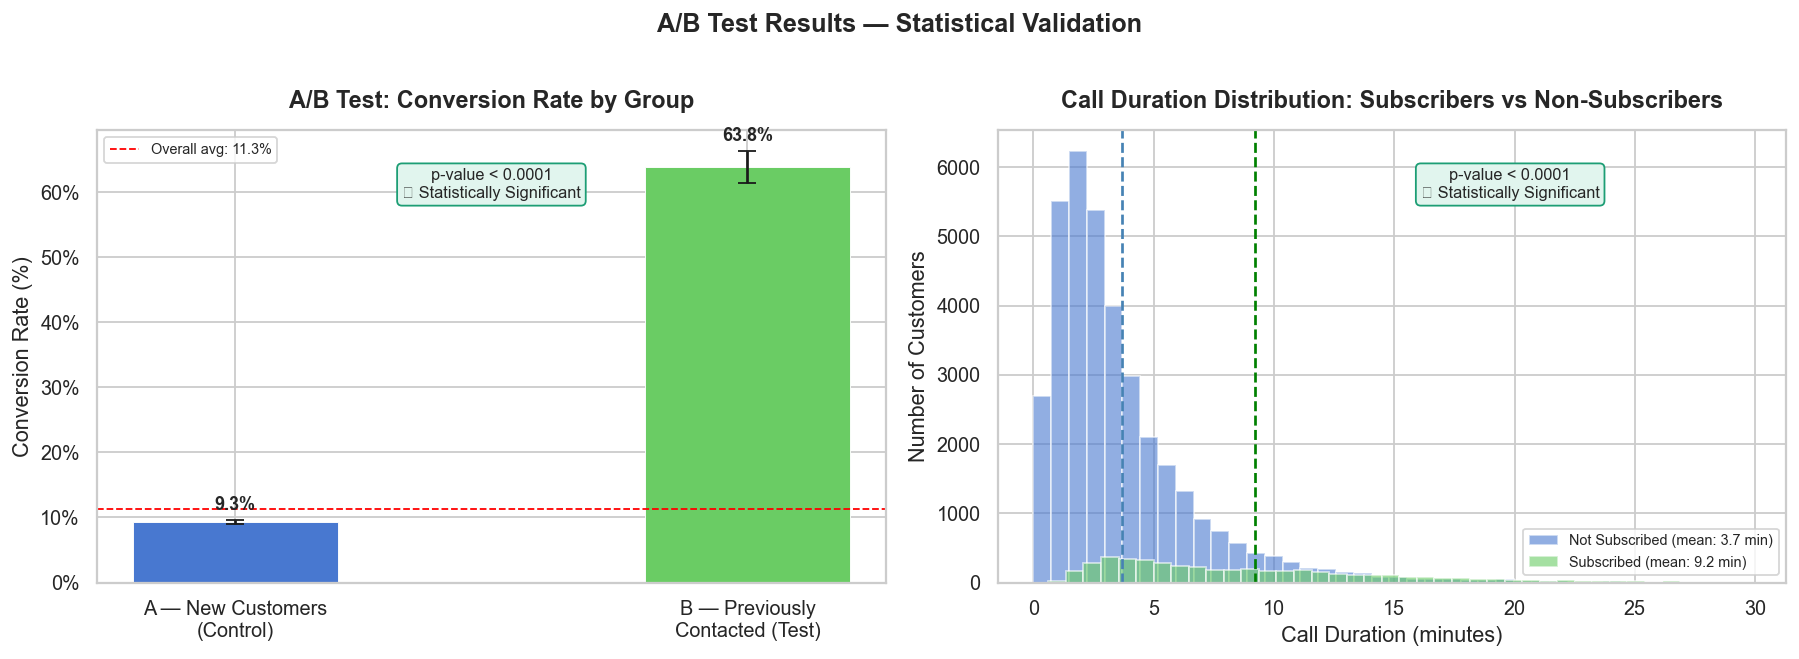

✓ Saved: ab_test_results.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("A/B Test Results — Statistical Validation",
             fontsize=14, fontweight="bold", y=1.01)

# ── Chart 1: Conversion rate by group with confidence intervals ───────────
ax1 = axes[0]

groups      = ["A — New Customers\n(Control)", "B — Previously\nContacted (Test)"]
conv_rates  = [group_a["subscribed_num"].mean() * 100,
               group_b["subscribed_num"].mean() * 100]

# Calculate 95% confidence intervals for each group
def confidence_interval_95(data):
    n    = len(data)
    mean = data.mean()
    se   = stats.sem(data)
    ci   = se * 1.96
    return ci

ci_a = confidence_interval_95(group_a["subscribed_num"]) * 100
ci_b = confidence_interval_95(group_b["subscribed_num"]) * 100

colors = [sns.color_palette("muted")[0], sns.color_palette("muted")[2]]
bars   = ax1.bar(groups, conv_rates, color=colors,
                 edgecolor="white", linewidth=0.5, width=0.4,
                 yerr=[ci_a, ci_b], capsize=5, error_kw={"linewidth": 1.5})

ax1.axhline(y=df["subscribed_num"].mean() * 100, color="red",
            linestyle="--", linewidth=1,
            label=f"Overall avg: {df['subscribed_num'].mean()*100:.1f}%")
ax1.set_ylabel("Conversion Rate (%)")
ax1.set_title("A/B Test: Conversion Rate by Group")
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax1.legend(fontsize=8)

for bar, val, ci in zip(bars, conv_rates, [ci_a, ci_b]):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + ci + 1,
             f"{val:.1f}%", ha="center", va="bottom", fontsize=10,
             fontweight="bold")

ax1.annotate(f"p-value < 0.0001\n✓ Statistically Significant",
             xy=(0.5, 0.85), xycoords="axes fraction",
             ha="center", fontsize=9,
             bbox=dict(boxstyle="round,pad=0.3",
                       facecolor="#E1F5EE", edgecolor="#1D9E75"))

# ── Chart 2: Call duration distribution by outcome ────────────────────────
ax2 = axes[1]

# Cap at 30 minutes for readability — extreme outliers skew the chart
dur_sub     = duration_subscribed[duration_subscribed <= 30]
dur_not_sub = duration_not_subscribed[duration_not_subscribed <= 30]

ax2.hist(dur_not_sub, bins=40, alpha=0.6,
         color=sns.color_palette("muted")[0],
         label=f"Not Subscribed (mean: {duration_not_subscribed.mean():.1f} min)")
ax2.hist(dur_sub, bins=40, alpha=0.6,
         color=sns.color_palette("muted")[2],
         label=f"Subscribed (mean: {duration_subscribed.mean():.1f} min)")

ax2.axvline(x=duration_not_subscribed.mean(), color="steelblue",
            linestyle="--", linewidth=1.5)
ax2.axvline(x=duration_subscribed.mean(), color="green",
            linestyle="--", linewidth=1.5)

ax2.set_xlabel("Call Duration (minutes)")
ax2.set_ylabel("Number of Customers")
ax2.set_title("Call Duration Distribution: Subscribers vs Non-Subscribers")
ax2.legend(fontsize=8)
ax2.annotate(f"p-value < 0.0001\n✓ Statistically Significant",
             xy=(0.65, 0.85), xycoords="axes fraction",
             ha="center", fontsize=9,
             bbox=dict(boxstyle="round,pad=0.3",
                       facecolor="#E1F5EE", edgecolor="#1D9E75"))

plt.tight_layout()
plt.savefig("C:/Users/savin/Downloads/bank-marketing-analysis/reports/ab_test_results.png", bbox_inches="tight", dpi=150)
plt.show()
print("✓ Saved: ab_test_results.png")

In [6]:
print("""
================================================================
BUSINESS RECOMMENDATION — BASED ON STATISTICAL ANALYSIS
================================================================

TEST 1: Chi-Square Test — Conversion Rate Difference
----------------------------------------------------------------
Hypothesis : Previously contacted customers convert at the same
             rate as new customers (null hypothesis)
Result     : REJECTED at 95% confidence (p < 0.0001)
Finding    : Previously contacted customers convert at 63.83%
             vs 9.26% for new customers — a 6.9x difference
             that is statistically proven to be real.

TEST 2: Two-Sample T-Test — Call Duration Difference
----------------------------------------------------------------
Hypothesis : Subscribers and non-subscribers have the same
             average call duration (null hypothesis)
Result     : REJECTED at 95% confidence (p < 0.0001)
Finding    : Subscribers average 9.19 min vs 3.67 min for
             non-subscribers — longer calls are a genuine
             and statistically proven signal of intent.

RECOMMENDATIONS FOR NEXT CAMPAIGN CYCLE
----------------------------------------------------------------
1. PRIORITISE previously contacted customers — allocate at
   least 60% of outreach budget to this segment first.

2. USE CELLULAR exclusively — 14.74% vs 5.23% conversion.
   Reallocate telephone budget to cellular campaigns.

3. CAP CONTACTS at 2 per customer — conversion drops below
   average from contact 3 onwards. Every extra call is waste.

4. SCHEDULE campaigns in March, September, and October —
   these months consistently outperform the annual average.

5. TARGET students (31.43%) and retired (25.26%) customers
   as priority segments alongside previously contacted ones.

Projected impact: Focusing budget on the top combination
(cellular + previously contacted + March) could realistically
achieve 50–65% conversion vs the current 11.27% average.
================================================================
""")


BUSINESS RECOMMENDATION — BASED ON STATISTICAL ANALYSIS

TEST 1: Chi-Square Test — Conversion Rate Difference
----------------------------------------------------------------
Hypothesis : Previously contacted customers convert at the same
             rate as new customers (null hypothesis)
Result     : REJECTED at 95% confidence (p < 0.0001)
Finding    : Previously contacted customers convert at 63.83%
             vs 9.26% for new customers — a 6.9x difference
             that is statistically proven to be real.

TEST 2: Two-Sample T-Test — Call Duration Difference
----------------------------------------------------------------
Hypothesis : Subscribers and non-subscribers have the same
             average call duration (null hypothesis)
Result     : REJECTED at 95% confidence (p < 0.0001)
Finding    : Subscribers average 9.19 min vs 3.67 min for
             non-subscribers — longer calls are a genuine
             and statistically proven signal of intent.

RECOMMENDATIONS FOR N